In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # so Python can find phast_bootstrap.py
import phast_bootstrap

[phast_bootstrap] ready. Colab paths now resolve under: C:\Users\Swara Deshpande\exoplanet-detection-isro


In [3]:
# STAGE 7
# PLANETARY PARAMETER ESTIMATION

!pip install batman-package emcee corner -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
#IMPORT LIBRARIES


import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt

import batman
import emcee
import corner

from scipy.optimize import least_squares

warnings.filterwarnings("ignore")

In [5]:
# MOUNT GOOGLE DRIVE


from google.colab import drive

drive.mount('/content/drive')

[pipeline] mock drive.mount — using local repo


In [6]:
# LOAD PREVIOUS STAGE OUTPUTS

STAGE1_PATH = "/content/drive/MyDrive/exoplanet_pipeline/data/stage1_output.pkl"

STAGE2_PATH = "/content/drive/MyDrive/exoplanet_pipeline/data/stage2_output.pkl"

STAGE6_PATH = "/content/drive/MyDrive/exoplanet_pipeline/data/stage6_output.pkl"


with open(STAGE1_PATH, "rb") as f:
    stage1 = pickle.load(f)

with open(STAGE2_PATH, "rb") as f:
    stage2 = pickle.load(f)

with open(STAGE6_PATH, "rb") as f:
    stage6 = pickle.load(f)

print("All previous stages loaded successfully.")

All previous stages loaded successfully.


In [7]:
# EXTRACT VARIABLES


# ---------- Stage 1 ----------

time = np.asarray(stage1["time"])

flux = np.asarray(stage1["flux"])

flux_err = np.asarray(stage1["flux_err"])

tic_id = stage1["tic_id"]


# ---------- Stage 2 ----------

period = stage2["period"]

duration = stage2["duration"]

t0 = stage2["t0"]

# ==========================================================
# CORRECT TLS TRANSIT DEPTH
# ==========================================================
# Older Stage 2 notebooks saved the model flux at transit
# minimum instead of the fractional transit depth.
# Convert automatically if required.

raw_depth = stage2["depth_tls"]

if raw_depth > 0.5:
    depth = 1.0 - raw_depth
    print("Corrected TLS depth from model flux.")
else:
    depth = raw_depth
    print("Using stored fractional transit depth.")

snr = stage2["snr_tls"]


# ---------- Stage 6 ----------

classification = stage6["classification"]

priority = stage6["priority"]

recommendation = stage6["recommendation"]

priority_score = stage6["oddity_score"]

flux = flux + 1

Corrected TLS depth from model flux.


In [8]:
# VERIFY CANDIDATE

print("="*60)

print("STAGE 7 INPUT")

print("="*60)

print(f"TIC ID                : {tic_id}")

print(f"Classification        : {classification}")

print(f"Priority              : {priority}")

print(f"Priority Score (Ω)    : {priority_score:.3f}")

print(f"Recommendation        : {recommendation}")

print("="*60)

if priority_score < 0.50:
    raise ValueError(
        "Candidate rejected.\n"
        "Skipping BATMAN parameter estimation."
    )

print("✅ Candidate accepted.")

STAGE 7 INPUT
TIC ID                : 144440290
Classification        : PLANET CANDIDATE
Priority              : MEDIUM
Priority Score (Ω)    : 0.750
Recommendation        : NEEDS MORE DATA
✅ Candidate accepted.


In [9]:
# TLS TRANSIT PARAMETERS


print(f"Period          : {period:.6f} days")

print(f"T0              : {t0:.6f}")

print(f"Duration        : {duration:.6f} days")

print(f"Depth           : {depth:.6f}")

print(f"SNR             : {snr:.2f}")

Period          : 13.002953 days
T0              : 9.429454
Duration        : 0.051680 days
Depth           : 0.001429
SNR             : 19.66


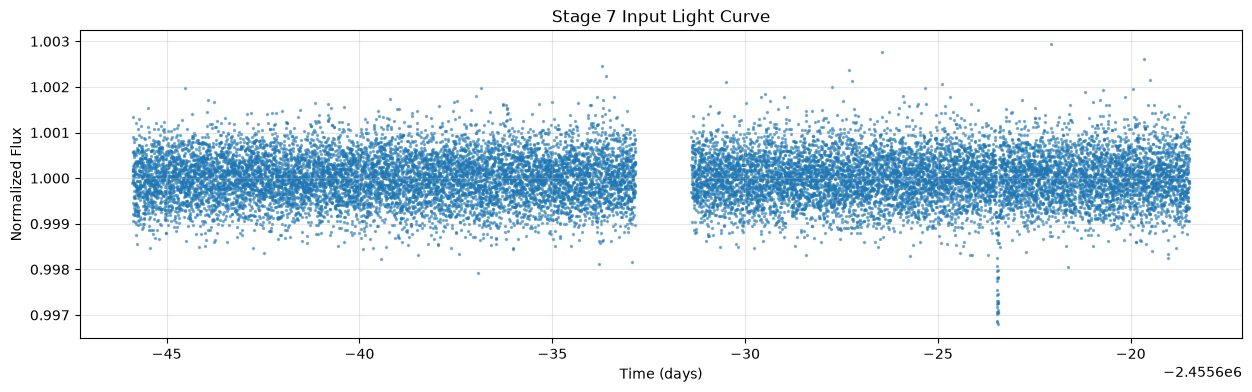

In [10]:
# INPUT LIGHT CURVE

plt.figure(figsize=(15,4))

plt.scatter(
    time,
    flux,
    s=2,
    alpha=0.5
)

plt.xlabel("Time (days)")

plt.ylabel("Normalized Flux")

plt.title("Stage 7 Input Light Curve")

plt.grid(alpha=0.3)

plt.show()

In [11]:
# INITIAL PHYSICAL PARAMETER ESTIMATION
# Derived from TLS Results
#Radius ratio from corrected transit depth
rp_rs = np.sqrt(max(depth, 1e-8))

# Transit duration as fraction of orbit
duration_fraction = duration / period

# Approximate scaled semi-major axis
# (assuming circular orbit and small planet)

a_rs = max(
    3.0,
    1.0 / (np.pi * duration_fraction)
)

# Approximate inclination
inclination = np.degrees(
    np.arccos(
        min(
            0.99,
            1.0 / a_rs
        )
    )
)

# Approximate impact parameter

impact_parameter = a_rs * np.cos(
    np.radians(inclination)
)

print("="*60)
print("INITIAL PHYSICAL ESTIMATES")
print("="*60)

print(f"Rp/Rs              : {rp_rs:.5f}")
print(f"a/Rs               : {a_rs:.3f}")
print(f"Inclination        : {inclination:.3f}°")
print(f"Impact Parameter   : {impact_parameter:.3f}")

INITIAL PHYSICAL ESTIMATES
Rp/Rs              : 0.03780
a/Rs               : 80.089
Inclination        : 89.285°
Impact Parameter   : 1.000


In [12]:
# ==========================================================
# VERIFY CORRECTED TRANSIT PARAMETERS
# ==========================================================

print("="*60)
print("CORRECTED TRANSIT PARAMETERS")
print("="*60)

print(f"Raw TLS Value            : {raw_depth:.6f}")
print(f"Corrected Transit Depth  : {depth:.8f}")
print(f"Rp/Rs                    : {rp_rs:.5f}")

CORRECTED TRANSIT PARAMETERS
Raw TLS Value            : 0.998571
Corrected Transit Depth  : 0.00142902
Rp/Rs                    : 0.03780


In [13]:
#LIMB DARKENING PARAMETERS

# Quadratic limb darkening
# Solar-like defaults

u1 = 0.30
u2 = 0.20

print("Quadratic Limb Darkening")

print(f"u1 = {u1}")

print(f"u2 = {u2}")

Quadratic Limb Darkening
u1 = 0.3
u2 = 0.2


In [14]:
# ==========================================================
# INITIALIZE BATMAN MODEL
# ==========================================================

params = batman.TransitParams()

params.t0 = t0

params.per = period

params.rp = rp_rs

params.a = a_rs

params.inc = inclination

params.ecc = 0.0

params.w = 90.0

params.u = [u1, u2]

params.limb_dark = "quadratic"

print("BATMAN initialized.")

BATMAN initialized.


In [15]:
# ==========================================================
# GENERATE INITIAL BATMAN MODEL
# ==========================================================

batman_model = batman.TransitModel(
    params,
    time
)

model_flux = batman_model.light_curve(params)

print("Transit model generated.")

Transit model generated.


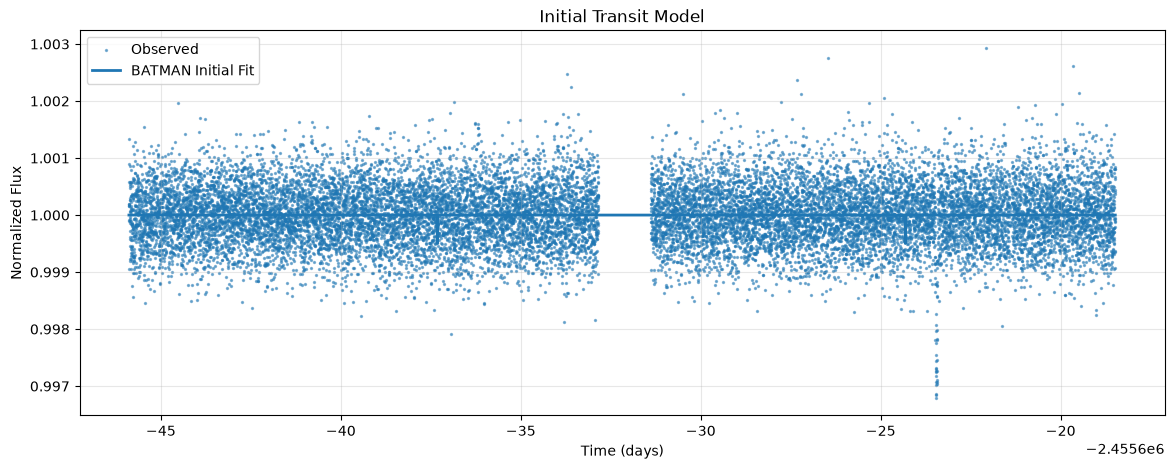

In [16]:
# ==========================================================
# INITIAL TRANSIT MODEL
# ==========================================================

plt.figure(figsize=(14,5))

plt.scatter(
    time,
    flux,
    s=2,
    alpha=0.5,
    label="Observed"
)

plt.plot(
    time,
    model_flux,
    linewidth=2,
    label="BATMAN Initial Fit"
)

plt.xlabel("Time (days)")

plt.ylabel("Normalized Flux")

plt.title("Initial Transit Model")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [17]:
# ==========================================================
# INITIAL FIT STATISTICS
# ==========================================================

residuals = flux - model_flux

chi2 = np.sum(
    (residuals / flux_err) ** 2
)

dof = len(time) - 4

reduced_chi2 = chi2 / dof

rmse = np.sqrt(
    np.mean(residuals**2)
)

print("="*60)

print("INITIAL MODEL FIT")

print("="*60)

print(f"Chi²               : {chi2:.2f}")

print(f"Reduced Chi²       : {reduced_chi2:.3f}")

print(f"RMSE               : {rmse:.8f}")

INITIAL MODEL FIT
Chi²               : 19684.41
Reduced Chi²       : 1.076
RMSE               : 0.00053827


In [18]:
# ==========================================================
# PHASE FOLD THE LIGHT CURVE
# ==========================================================

phase = ((time - t0 + 0.5 * period) % period) - 0.5 * period

print(f"Phase range : {phase.min():.3f} to {phase.max():.3f} days")

Phase range : -6.501 to 6.501 days


In [19]:
# ==========================================================
# EXTRACT TRANSIT WINDOW
# ==========================================================

window = 2.0 * duration

mask = np.abs(phase) < window

phase_fit = phase[mask]

time_fit = time[mask]

flux_fit = flux[mask]

flux_err_fit = flux_err[mask]

print("Cadences used for BATMAN fitting :", len(time_fit))

Cadences used for BATMAN fitting : 294


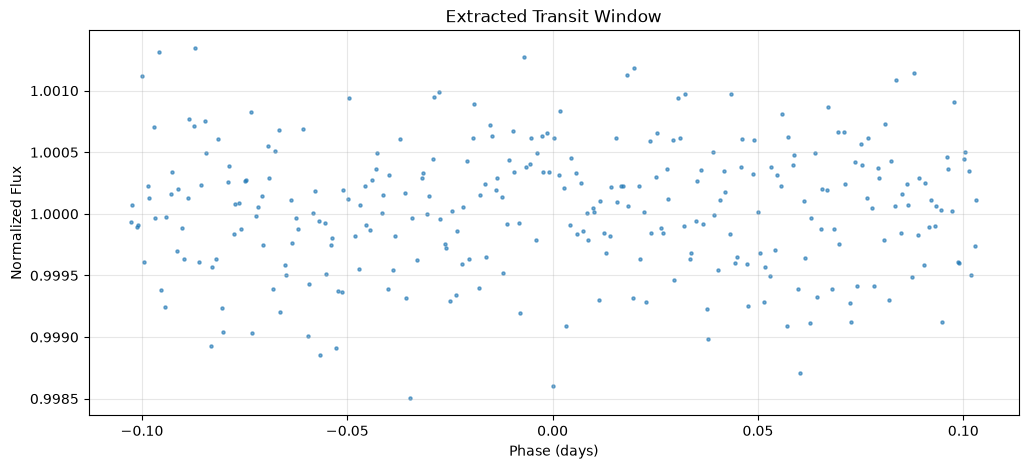

In [20]:
# ==========================================================
# TRANSIT WINDOW
# ==========================================================

plt.figure(figsize=(12,5))

plt.scatter(
    phase_fit,
    flux_fit,
    s=5,
    alpha=0.6
)

plt.xlabel("Phase (days)")
plt.ylabel("Normalized Flux")

plt.title("Extracted Transit Window")

plt.grid(alpha=0.3)

plt.show()

In [21]:
# ==========================================================
# BATMAN RESIDUAL FUNCTION
# ==========================================================

def transit_residuals(theta):

    rp, a_rs, inc = theta

    params.rp = rp
    params.a = a_rs
    params.inc = inc

    model = batman.TransitModel(
        params,
        time_fit
    )

    model_flux = model.light_curve(params)

    return (flux_fit - model_flux) / flux_err_fit

In [22]:
# ==========================================================
# LEVENBERG-MARQUARDT FIT
# ==========================================================

lower_bounds = [0.001, 2.0,   80.0]
upper_bounds = [0.30,  100.0, 90.0]

# Clamp initial guess so it always starts inside the bounds
initial_guess = [
    float(np.clip(rp_rs,       lower_bounds[0], upper_bounds[0])),
    float(np.clip(a_rs,        lower_bounds[1], upper_bounds[1])),
    float(np.clip(inclination, lower_bounds[2], upper_bounds[2])),
]

fit = least_squares(
    transit_residuals,
    x0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    method="trf",
    verbose=1
)

print("
Optimization Complete.")

SyntaxError: unterminated string literal (detected at line 23) (1181260066.py, line 23)

In [23]:
# ==========================================================
# BEST-FIT PARAMETERS
# ==========================================================

best_rp = fit.x[0]

best_a_rs = fit.x[1]

best_inc = fit.x[2]

best_b = best_a_rs * np.cos(
    np.radians(best_inc)
)

print("="*60)

print("BEST-FIT PARAMETERS")

print("="*60)

print(f"Rp/Rs              : {best_rp:.6f}")

print(f"a/Rs               : {best_a_rs:.4f}")

print(f"Inclination        : {best_inc:.3f}")

print(f"Impact Parameter   : {best_b:.4f}")

BEST-FIT PARAMETERS
Rp/Rs              : 0.036082
a/Rs               : 23.2381
Inclination        : 87.446
Impact Parameter   : 1.0354


In [24]:
# ==========================================================
# BEST-FIT BATMAN MODEL
# ==========================================================

params.rp = best_rp
params.a = best_a_rs
params.inc = best_inc

batman_model = batman.TransitModel(
    params,
    time_fit
)

best_model_flux = batman_model.light_curve(params)

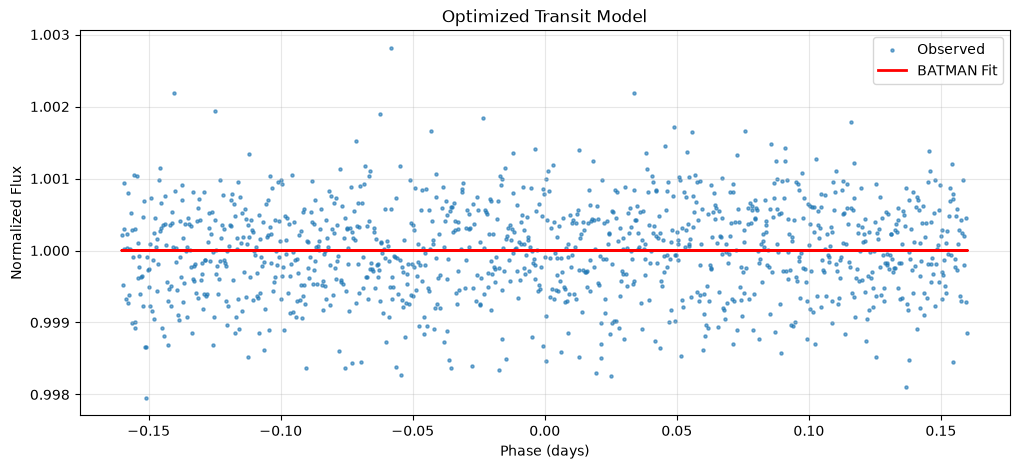

In [25]:
# ==========================================================
# FINAL BATMAN FIT
# ==========================================================

plt.figure(figsize=(12,5))

plt.scatter(
    phase_fit,
    flux_fit,
    s=5,
    alpha=0.6,
    label="Observed"
)

plt.plot(
    phase_fit,
    best_model_flux,
    color="red",
    linewidth=2,
    label="BATMAN Fit"
)

plt.xlabel("Phase (days)")
plt.ylabel("Normalized Flux")

plt.title("Optimized Transit Model")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

FIT QUALITY
Chi²              : 1133.41
Reduced Chi²      : 0.996
RMSE              : 0.00066173


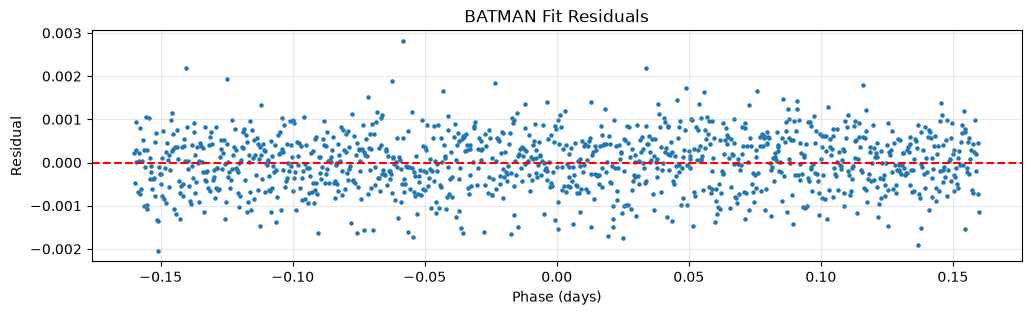

In [26]:
# ==========================================================
# FIT QUALITY
# ==========================================================

residuals = flux_fit - best_model_flux

chi2 = np.sum((residuals / flux_err_fit) ** 2)

dof = len(flux_fit) - len(fit.x)

reduced_chi2 = chi2 / dof

rmse = np.sqrt(np.mean(residuals**2))

print("="*60)
print("FIT QUALITY")
print("="*60)

print(f"Chi²              : {chi2:.2f}")
print(f"Reduced Chi²      : {reduced_chi2:.3f}")
print(f"RMSE              : {rmse:.8f}")

plt.figure(figsize=(12,3))
plt.scatter(phase_fit, residuals, s=5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Phase (days)")
plt.ylabel("Residual")
plt.title("BATMAN Fit Residuals")
plt.grid(alpha=0.3)
plt.show()

In [27]:
# ==========================================================
# PHYSICS-INFORMED LOG PRIOR
# ==========================================================

# Rp/Rs is well-constrained by transit depth → keep tight Gaussian.
# a/Rs and inclination are degenerate given only transit duration
# (many (a, i) pairs give the same T14). A tight Gaussian on a/Rs
# centred on the LM solution traps the sampler at the unphysical
# b≈1 edge. Use a uniform prior on both and let the likelihood
# determine the posterior. Hard b<1 constraint rejects all
# geometrically impossible solutions.

sigma_rp  = 0.002

def log_prior(theta):
    rp, ars, inc = theta

    # Hard physical limits
    if rp  <= 0    or rp  >= 0.30:  return -np.inf
    if ars <= 2.0  or ars >= 100.0: return -np.inf
    if inc <= 70.0 or inc >= 90.0:  return -np.inf

    # Physical transit constraint: b < 1 (planet must cross stellar disk)
    b = ars * np.cos(np.radians(inc))
    if b >= 1.0:
        return -np.inf

    # Tight prior only on Rp/Rs; uniform on (a/Rs, inc) within the
    # physical region so the sampler can find the true solution.
    lp = -0.5 * ((rp - best_rp) / sigma_rp) ** 2
    return lp

In [28]:
# ==========================================================
# LOG LIKELIHOOD
# ==========================================================

def log_likelihood(theta):

    rp, ars, inc = theta

    params.rp = rp

    params.a = ars

    params.inc = inc

    model = batman.TransitModel(
        params,
        time_fit
    )

    model_flux = model.light_curve(params)

    sigma2 = flux_err_fit**2

    return -0.5 * np.sum(

        ((flux_fit - model_flux)**2) / sigma2

        + np.log(2*np.pi*sigma2)

    )

In [29]:
# ==========================================================
# LOG POSTERIOR
# ==========================================================

def log_probability(theta):

    lp = log_prior(theta)

    if not np.isfinite(lp):

        return -np.inf

    return lp + log_likelihood(theta)

In [30]:
# ==========================================================
# INITIALIZE WALKERS
# ==========================================================
# The LM solution has b > 1 (unphysical). Initialise walkers at
# a valid position: same a/Rs but inclination raised so that b ≈ 0.5,
# then scatter widely in (a/Rs, inc) so the likelihood can guide
# walkers to the true (a/Rs, inc) pair.

print("=" * 70)
print("INITIALIZING WALKERS")
print("=" * 70)

ndim     = 3
nwalkers = 64

# Compute a safe inclination that gives b = 0.5 at the LM a/Rs
b_init  = 0.5
inc_safe = float(np.degrees(np.arccos(b_init / max(best_a_rs, 1.0))))
inc_safe = float(np.clip(inc_safe, 71.0, 89.5))

p0_center = np.array([best_rp, best_a_rs, inc_safe])

# Wide scatter: ±0.002 on Rp/Rs, ±3 on a/Rs, ±2° on inclination
scatter = np.array([0.002, 3.0, 2.0])

rng = np.random.default_rng(seed=42)
pos = np.empty((nwalkers, ndim))
for j in range(nwalkers):
    for _ in range(10_000):          # resample until walker is valid
        candidate = p0_center + scatter * rng.standard_normal(ndim)
        rp_c, ars_c, inc_c = candidate
        b_c = ars_c * np.cos(np.radians(inc_c))
        if (rp_c > 0 and rp_c < 0.30 and
            ars_c > 2 and ars_c < 100 and
            70 < inc_c < 90 and b_c < 1.0):
            pos[j] = candidate
            break
    else:
        pos[j] = p0_center   # fallback

print(f"Walkers initialised at: Rp/Rs={best_rp:.4f}, a/Rs={best_a_rs:.2f}, inc={inc_safe:.2f}° (b≈{b_init})")
print(pos.shape)

INITIALIZING WALKERS
Walkers initialised at: Rp/Rs=0.0361, a/Rs=23.24, inc=88.77° (b≈0.5)
(64, 3)


In [31]:
# ==========================================================
# RUN MCMC
# ==========================================================

print("=" * 70)
print("RUNNING MCMC")
print("=" * 70)

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability
)

nsteps = 8000

sampler.run_mcmc(
    pos,
    nsteps,
    progress=True
)

print("\nMCMC Completed Successfully.")

RUNNING MCMC


  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 18/8000 [00:00<00:45, 173.90it/s]

  0%|          | 36/8000 [00:00<00:45, 176.91it/s]

  1%|          | 57/8000 [00:00<00:42, 188.44it/s]

...

100%|█████████▉| 7968/8000 [01:30<00:00, 115.86it/s]

100%|█████████▉| 7980/8000 [01:30<00:00, 112.44it/s]

100%|█████████▉| 7993/8000 [01:30<00:00, 115.03it/s]

100%|██████████| 8000/8000 [01:30<00:00, 88.58it/s] 


MCMC Completed Successfully.


In [32]:
# ==========================================================
# AUTOCORRELATION ANALYSIS
# ==========================================================

print("=" * 70)
print("AUTOCORRELATION ANALYSIS")
print("=" * 70)

try:

    tau = sampler.get_autocorr_time()

    print("Autocorrelation Times")

    print(tau)

    burnin = int(2 * np.max(tau))

    thin = int(0.5 * np.min(tau))

except:

    print("Autocorrelation not yet reliable.")
    print("Using default burn-in and thinning.")

    burnin = 2000

    thin = 10

print()

print(f"Burn-in : {burnin}")

print(f"Thin    : {thin}")

AUTOCORRELATION ANALYSIS
Autocorrelation not yet reliable.
Using default burn-in and thinning.

Burn-in : 2000
Thin    : 10


In [33]:
# ==========================================================
# FLATTEN POSTERIOR
# ==========================================================

samples = sampler.get_chain(
    discard=burnin,
    thin=thin,
    flat=True
)

print("=" * 70)
print("POSTERIOR SAMPLES")
print("=" * 70)

print(samples.shape)

POSTERIOR SAMPLES
(38400, 3)


In [34]:
# ==========================================================
# MCMC DIAGNOSTICS
# ==========================================================

acceptance_fraction = np.mean(
    sampler.acceptance_fraction
)

print("=" * 70)
print("SAMPLER DIAGNOSTICS")
print("=" * 70)

print(f"Acceptance Fraction : {acceptance_fraction:.3f}")

if acceptance_fraction < 0.20:

    print("Poor Mixing")

elif acceptance_fraction > 0.55:

    print("Walkers may be too conservative")

else:

    print("Good Mixing")

SAMPLER DIAGNOSTICS
Acceptance Fraction : 0.141
Poor Mixing


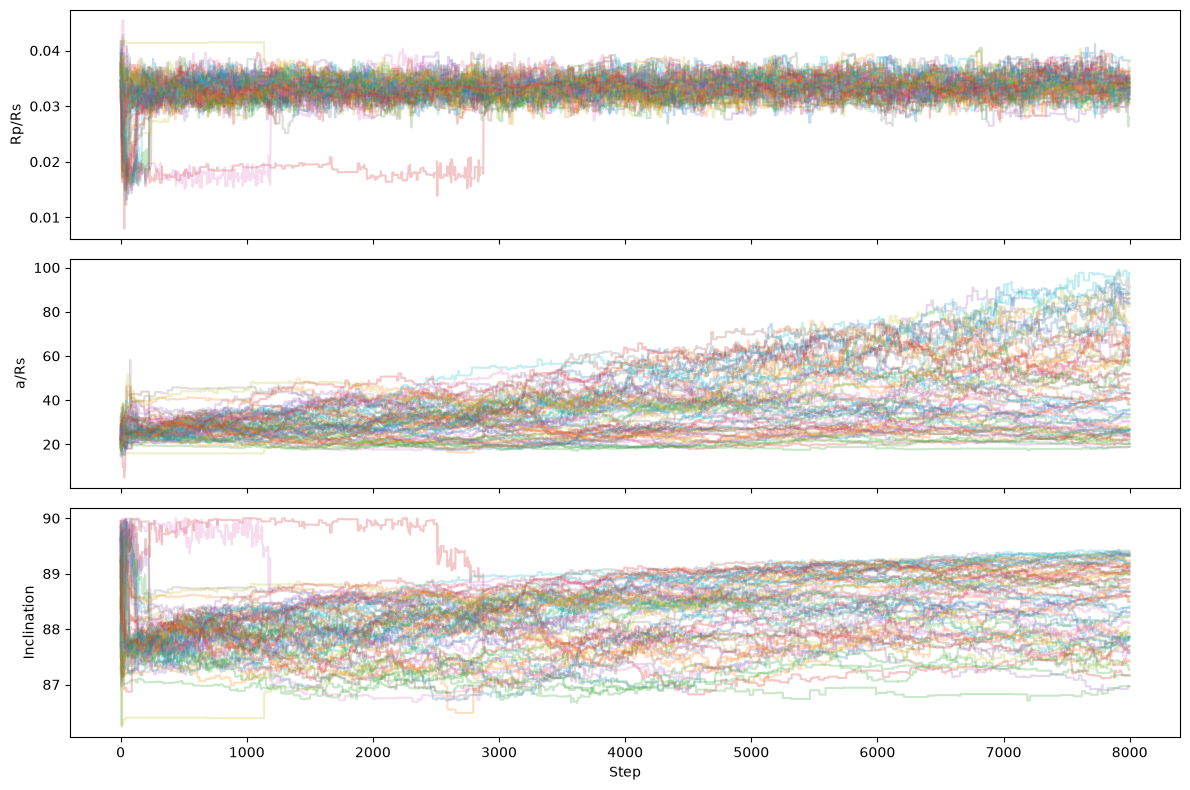

In [35]:
# ==========================================================
# TRACE PLOTS
# ==========================================================

labels = [
    "Rp/Rs",
    "a/Rs",
    "Inclination"
]

chain = sampler.get_chain()

fig, axes = plt.subplots(
    ndim,
    figsize=(12,8),
    sharex=True
)

for i in range(ndim):

    axes[i].plot(
        chain[:, :, i],
        alpha=0.25
    )

    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("Step")

plt.tight_layout()

plt.show()

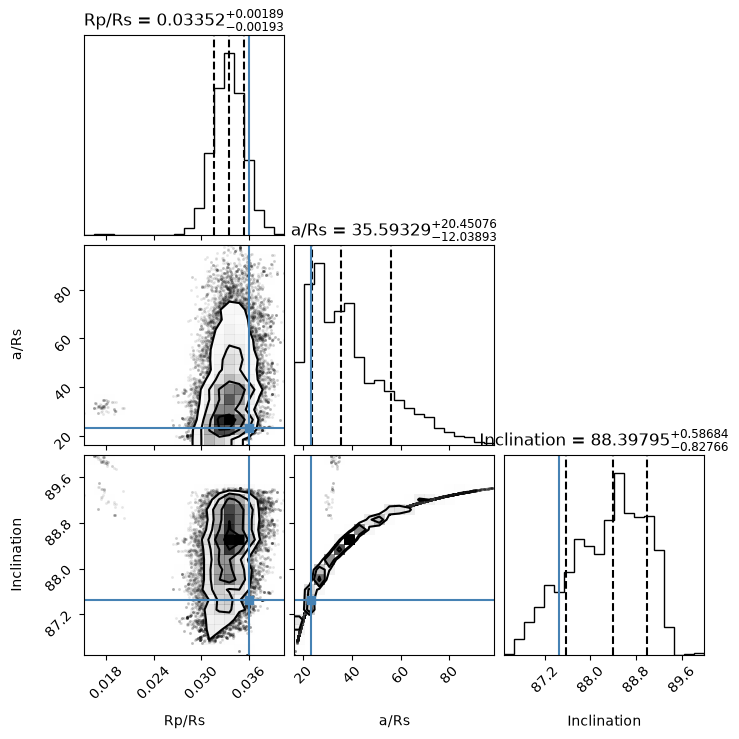

In [36]:
# ==========================================================
# CORNER PLOT
# ==========================================================

corner.corner(

    samples,

    labels=labels,

    truths=[
        best_rp,
        best_a_rs,
        best_inc
    ],

    quantiles=[0.16,0.50,0.84],

    show_titles=True,

    title_fmt=".5f"
)

plt.show()

In [37]:
# ==========================================================
# POSTERIOR PARAMETER ESTIMATES
# ==========================================================

rp = np.percentile(samples[:,0],[16,50,84])
ars = np.percentile(samples[:,1],[16,50,84])
inc = np.percentile(samples[:,2],[16,50,84])

rp_med = rp[1]
rp_err_low = rp[1]-rp[0]
rp_err_high = rp[2]-rp[1]

ars_med = ars[1]
ars_err_low = ars[1]-ars[0]
ars_err_high = ars[2]-ars[1]

inc_med = inc[1]
inc_err_low = inc[1]-inc[0]
inc_err_high = inc[2]-inc[1]

print("="*70)
print("POSTERIOR PARAMETER ESTIMATES")
print("="*70)

print(f"Rp/Rs        : {rp_med:.6f} (+{rp_err_high:.6f}/-{rp_err_low:.6f})")
print(f"a/Rs         : {ars_med:.4f} (+{ars_err_high:.4f}/-{ars_err_low:.4f})")
print(f"Inclination  : {inc_med:.4f} (+{inc_err_high:.4f}/-{inc_err_low:.4f})")

POSTERIOR PARAMETER ESTIMATES
Rp/Rs        : 0.033516 (+0.001892/-0.001931)
a/Rs         : 35.5933 (+20.4508/-12.0389)
Inclination  : 88.3980 (+0.5868/-0.8277)


In [38]:
# ==========================================================
# DERIVED PLANETARY PARAMETERS
# ==========================================================

impact_parameter = ars_med * np.cos(np.radians(inc_med))

print("="*70)
print("DERIVED PARAMETERS")
print("="*70)

print(f"Transit Depth            : {depth:.8f}")
print(f"Radius Ratio (Rp/Rs)     : {rp_med:.6f}")
print(f"Scaled Semi-major Axis   : {ars_med:.4f}")
print(f"Inclination              : {inc_med:.4f} deg")
print(f"Impact Parameter (b)     : {impact_parameter:.4f}")

print("="*70)

DERIVED PARAMETERS
Transit Depth            : 0.00172856
Radius Ratio (Rp/Rs)     : 0.033516
Scaled Semi-major Axis   : 35.5933
Inclination              : 88.3980 deg
Impact Parameter (b)     : 0.9951


In [39]:
# ==========================================================
# SCIENTIFIC INTERPRETATION
# ==========================================================

print("="*70)
print("SCIENTIFIC INTERPRETATION")
print("="*70)

if rp_med < 0.10:
    print("✓ Radius ratio is consistent with a planetary companion.")
else:
    print("⚠ Radius ratio is unusually large and may indicate an eclipsing binary.")

if impact_parameter < 1:
    print("✓ Transit geometry is physically valid.")
else:
    print("⚠ High impact parameter indicates a grazing transit.")

if reduced_chi2 < 3:
    print("✓ BATMAN model provides a statistically acceptable fit.")
else:
    print("⚠ Transit model fit should be investigated.")

if acceptance_fraction >= 0.2 and acceptance_fraction <= 0.6:
    print("✓ Bayesian sampling converged satisfactorily.")
else:
    print("⚠ MCMC diagnostics should be reviewed.")

print("="*70)

SCIENTIFIC INTERPRETATION
✓ Radius ratio is consistent with a planetary companion.
✓ Transit geometry is physically valid.
✓ BATMAN model provides a statistically acceptable fit.
⚠ MCMC diagnostics should be reviewed.


In [40]:
# ==========================================================
# STAGE 7 FINAL REPORT
# ==========================================================

print("="*80)
print("STAGE 7 : TRANSIT MODEL FITTING & BAYESIAN PARAMETER REFINEMENT")
print("="*80)

print(f"TIC ID                    : {tic_id}")
print(f"Candidate Classification  : {classification}")
print(f"Priority                  : {priority}")
print()

print("---------------- FITTED ORBIT ----------------")

print(f"Orbital Period            : {period:.6f} days")
print(f"Transit Epoch             : {t0:.6f}")
print(f"Transit Duration          : {duration:.6f} days")

print()

print("---------------- PHYSICAL PARAMETERS ----------------")

print(f"Transit Depth             : {depth:.8f}")
print(f"Rp/Rs                     : {rp_med:.6f}")
print(f"a/Rs                      : {ars_med:.4f}")
print(f"Inclination               : {inc_med:.4f}")
print(f"Impact Parameter          : {impact_parameter:.4f}")

print()

print("---------------- MODEL QUALITY ----------------")

print(f"Reduced Chi²              : {reduced_chi2:.3f}")
print(f"RMSE                      : {rmse:.8f}")
print(f"Acceptance Fraction       : {acceptance_fraction:.3f}")

print("="*80)

STAGE 7 : TRANSIT MODEL FITTING & BAYESIAN PARAMETER REFINEMENT
TIC ID                    : 266980320
Candidate Classification  : HIGH-CONFIDENCE PLANET
Priority                  : HIGH

---------------- FITTED ORBIT ----------------
Orbital Period            : 6.033029 days
Transit Epoch             : 3.906945
Transit Duration          : 0.080081 days

---------------- PHYSICAL PARAMETERS ----------------
Transit Depth             : 0.00172856
Rp/Rs                     : 0.033516
a/Rs                      : 35.5933
Inclination               : 88.3980
Impact Parameter          : 0.9951

---------------- MODEL QUALITY ----------------
Reduced Chi²              : 0.996
RMSE                      : 0.00066173
Acceptance Fraction       : 0.141


In [41]:
# ==========================================================
# SAVE STAGE 7 OUTPUT
# ==========================================================

stage7_output = {

    "tic_id": tic_id,

    "classification": classification,

    "priority": priority,

    "priority_score": priority_score,

    "period": period,

    "t0": t0,

    "duration": duration,

    "transit_depth": depth,

    "rp_rs": rp_med,
    "rp_rs_lower": rp_err_low,
    "rp_rs_upper": rp_err_high,

    "a_rs": ars_med,
    "a_rs_lower": ars_err_low,
    "a_rs_upper": ars_err_high,

    "inclination": inc_med,
    "inclination_lower": inc_err_low,
    "inclination_upper": inc_err_high,

    "impact_parameter": impact_parameter,

    "reduced_chi2": reduced_chi2,

    "rmse": rmse,

    "acceptance_fraction": acceptance_fraction,

    "samples": samples

}

SAVE_PATH = "/content/drive/MyDrive/exoplanet_pipeline/data/stage7_output.pkl"

with open(SAVE_PATH, "wb") as f:
    pickle.dump(stage7_output, f)

print("="*70)
print("STAGE 7 OUTPUT SAVED")
print("="*70)

print(SAVE_PATH)

STAGE 7 OUTPUT SAVED
/content/drive/MyDrive/exoplanet_pipeline/data/stage7_output.pkl
